In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
df = pd.read_parquet('output/df_merged_all_infos.parquet')
df_hist_abs_emissions = pd.read_parquet('data/transformed_data/hist_abs_emissions.parquet')
df_abs_em_rate = pd.read_parquet('data/transformed_data/hist_abs_emissions_growth_rate.parquet')
df_hist_intensities = pd.read_parquet('data/transformed_data/hist_intensities.parquet')
df_intensities_rate = pd.read_parquet('data/transformed_data/hist_intensities_growth_rate.parquet')
df_auto_intensities_rate = pd.read_parquet("data/transformed_data/df_auto_intensities_rate.parquet")

scopes = ["s1", "s2", "s3_d", "s3_u"]
regions = list(df['region_0'].unique())
list_high_impact_sector = list(df['high_impact_sector'].dropna().sort_values().unique())
years_str = sorted([c for c in df_hist_abs_emissions.columns if c.isdigit()], key=int, reverse=False)
dict_year_delta_years = {y: f"{int(y)-1}-{y}" for y in years_str[1:]}
delta_years_str = list(dict_year_delta_years.values())

df_eq_abs_em = pd.merge(df[['isin', 'scope','high_impact_sector', 'region_0']], df_hist_abs_emissions, how='left', on=['isin', 'scope'])
df_eq_abs_em_rate = pd.merge(df[['isin', 'scope','high_impact_sector', 'region_0']], df_abs_em_rate, how='left', on=['isin', 'scope'])
df_eq_intensities = pd.merge(df[['isin', 'scope','high_impact_sector', 'region_0']], df_hist_intensities, how='left', on=['isin', 'scope'])
df_eq_intensities_rate = pd.merge(df[['isin', 'scope','high_impact_sector', 'region_0']], 
                             df_intensities_rate[['isin', 'scope'] + delta_years_str], how='left', 
                             on=['isin', 'scope'])
df_eq_auto_intensities_rate = pd.merge(df[['isin', 'scope','high_impact_sector', 'region_0']], 
                             df_auto_intensities_rate[['isin', 'scope'] + delta_years_str], how='left', 
                             on=['isin', 'scope'])


# % emissions par scope

In [106]:
df_mapping_scope = pd.read_excel('data/climate_alignment_index_parameters.xlsx', 'mapping_sector_rel_scopes')
mapping_sector_scope = df_mapping_scope.set_index('high_impact_sector')['scopes'].to_dict()
scope_expand = {"s1":["s1"],"s12":["s1","s2"],"s3_d":["s3_d"],"s3_u":["s3_u"],"s13_u":["s1","s3_u"],"s123_u":["s1","s2","s3_u"], "s123_d":["s1","s2","s3_d"]}

In [107]:
df_abs_em = df_hist_abs_emissions.copy()
df_abs_em = df_abs_em[df_abs_em['scope'].isin(scopes)].assign(scope=lambda d: pd.Categorical(d["scope"], categories=scopes, ordered=True))
df_abs_em = pd.merge(df_abs_em, df[['isin', 'scope', 'high_impact_sector']], on=['isin', 'scope'], how='left')

In [108]:
df_abs_em["relevant_scope"] = df_abs_em["high_impact_sector"].map(mapping_sector_scope)
df_abs_em["is_relevant_scope"] = [
    s in scope_expand.get(e, []) for s, e in zip(df_abs_em["scope"], df_abs_em["relevant_scope"])]

In [109]:
sum_em_by_scope_by_sector_years = df_abs_em[df_abs_em['is_relevant_scope']].groupby(['high_impact_sector', 'scope'])[years_str].sum()
# sum_em_by_scope_by_sector_years.div(sum_em_by_scope_by_sector_years.groupby(level=0).sum(), level=0)

In [110]:
df_abs_em['average_emissions'] = df_abs_em[years_str].mean(axis=1)
sum_em_by_scope_by_sector = df_abs_em[df_abs_em['is_relevant_scope']].groupby(['high_impact_sector', 'scope'])['average_emissions'].sum()
sum_em_by_scope_by_sector.div(sum_em_by_scope_by_sector.groupby(level=0).sum(), level=0)

high_impact_sector                 scope
Agriculture, forestry and fishing  s1       0.124290
                                   s3_u     0.875710
Airlines                           s1       1.000000
Aluminium                          s1       0.722538
                                   s2       0.277462
Automobiles                        s1       0.010839
                                   s2       0.016965
                                   s3_d     0.972196
Banking                            s3_d     1.000000
Cement                             s1       1.000000
Chemicals                          s1       0.682207
                                   s2       0.317793
Coal mining                        s1       0.879241
                                   s2       0.120759
Consumer goods & services          s1       0.419747
                                   s2       0.580253
Diversified mining                 s1       0.683990
                                   s2       0.316010
Elect

# intensity by prod for auto scp3

###  retrouver les 164

In [41]:
selected_region_0 =regions
selected_hisector_0 = ['Automobiles']
selected_scope_0 =  "s3_d"
df_selection_all_col_1 = df_eq_abs_em_rate[(df_eq_abs_em_rate['region_0'].isin(selected_region_0))&(
    df_eq_abs_em_rate['high_impact_sector'].isin(selected_hisector_0))&(
        df_eq_abs_em_rate['scope']==selected_scope_0)].copy()

df_selection_all_col_1['last_available_year'] = df_selection_all_col_1[delta_years_str[::-1]].bfill(axis=1).iloc[:, 0]

df_selection_1 = df_selection_all_col_1[['isin', 'scope'] + delta_years_str + ['last_available_year']].copy()
selected_year_1 = ['2020-2021', '2021-2022', '2022-2023']

if not selected_year_1:
    selected_year_1 = delta_years_str

df_selection_1_mean = pd.concat([df_selection_1['scope'], df_selection_1[selected_year_1].mean(axis=1).rename("mean_value")], axis=1)
df_stats_1 = df_selection_1_mean.groupby('scope')['mean_value'].describe()

In [42]:
df_stats_1

,count,mean,std,min,25%,50%,75%,max
scope,,,,,,,,
s3_d,164.0,399.120985,5072.462692,-0.74087,0.146168,0.776977,1.594784,64962.057435


### parmis eux voir la couverture des data de prod

In [5]:
df_moodys = pd.read_excel("C:/Users/A_PORTEU/SciBetaTeam Dropbox/Aurore Porteu de La Morandière/ScientificAnalytics/ESG/esg_data/moodys/Mra_Rl_Temperature_Alignment_2050_2024_10.xlsx", 
                          sheet_name="Full")

In [6]:
df_moodys[df_moodys['Generic Sector']=='Automobiles']['Unit'].unique()

array(['tCO2e',
       'Emission Intensity by Product (passenger vehicles) in gCO2/vkm',
       'Emission Intensity by Product (Electricity) in gCO2/kWh'],
      dtype=object)

In [7]:
intensity_kind = 'Emission Intensity by Product (passenger vehicles) in gCO2/vkm'
df_auto_int = df_moodys[df_moodys['Generic Sector']=='Automobiles'].query(f"Unit=='{intensity_kind}'")[
    ['ISIN', 'Data Type', 'Scope'] + years_str].rename(columns={'ISIN': 'isin'})
df_auto_int[years_str] = df_auto_int[years_str].replace('NI', np.nan)
df_auto_int = df_auto_int[~df_auto_int[years_str].isna().all(axis=1)]
print("check il n'y a bien que le scope 3:", df_auto_int['Scope'].unique())
# on sait que toutes les eq qui ont ces donnes l'ont au moins en historical data
df_auto_int = df_auto_int[df_auto_int['Data Type']=='Historical Data']
df_auto_int['Scope'] = df_auto_int['Scope'].replace('Scope 3', 's3_d')
df_auto_int = df_auto_int.rename(columns={'Scope': 'scope', 'Data Type': 'data_type'})
# coverage_intensity_km.style.format("{:.2%}")

check il n'y a bien que le scope 3: ['Scope 3']


C:\Users\A_PORTEU\AppData\Local\Temp\ipykernel_36664\1073371447.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_auto_int[years_str] = df_auto_int[years_str].replace('NI', np.nan)


In [8]:
df_merge = pd.merge(df_selection_1[['isin', 'scope', 'last_available_year']], df_auto_int[['isin', 'scope', 'data_type']], 
         on=['isin', 'scope'], how='left')
df_merge_w = pd.merge(df_merge, df[df['high_impact_sector']=='Automobiles'].groupby('isin').first()['s_mc_weight'].reset_index(), on='isin', how='left')
print(df_merge.notna()[['isin', 'last_available_year', 'data_type']].sum())
print('coverage emissions rate for automobile sector:', f'{df_merge_w.loc[df_merge_w['last_available_year'].notna(), 's_mc_weight'].sum():.1%}')
print('coverage intensity emissions by km:', f'{df_merge_w.loc[df_merge_w['data_type'].notna(), 's_mc_weight'].sum():.1%}')

isin                   186
last_available_year    164
data_type               16
dtype: int64
coverage emissions rate for automobile sector: 97.7%
coverage intensity emissions by km: 53.5%


### Avec les fichiers clean maintenant

In [9]:
# test 1: voir de nombre d'equities qui ont au moins 3 inferieures a 10%
threshold = 0.1
df_selection_all_col_1['at_least_3_rate_no_outlier'] = ((df_selection_all_col_1[delta_years_str]<threshold).sum(axis=1)>=3)
print("nombre d'equities qui ont au moins 3 inferieures a 10%:", df_selection_all_col_1['at_least_3_rate_no_outlier'].sum())
list_eq_not_pass_test_1 = df_selection_all_col_1[~df_selection_all_col_1['at_least_3_rate_no_outlier']]['isin'].to_list()
list_eq_pass_test_1 = df_selection_all_col_1[df_selection_all_col_1['at_least_3_rate_no_outlier']]['isin'].to_list()


nombre d'equities qui ont au moins 3 inferieures a 10%: 38


In [10]:
# test 2: parmi les equities qui ont au moins 2 taux superieurs a 10%, peut on en repecher grave au intensites?
df_selection_all_col_3 = df_eq_intensities_rate[(df_eq_intensities_rate['region_0'].isin(selected_region_0))&(
    df_eq_intensities_rate['high_impact_sector'].isin(selected_hisector_0))&(
        df_eq_intensities_rate['scope']==selected_scope_0)].copy()
df_selection_all_col_3['last_available_year'] = df_selection_all_col_3[delta_years_str[::-1]].bfill(axis=1).iloc[:, 0]

df_selection_all_col_3_test_1 = df_selection_all_col_3[df_selection_all_col_3['isin'].isin(list_eq_not_pass_test_1)].copy()
df_selection_all_col_3_test_1['at_least_3_rate_no_outlier'] = ((df_selection_all_col_3_test_1[delta_years_str]<threshold).sum(axis=1)>=3)
print("nombre d'equities qui ont au moins 3 inferieures a 10%:", df_selection_all_col_3_test_1['at_least_3_rate_no_outlier'].sum())
list_eq_not_pass_test_2 = df_selection_all_col_3_test_1[~df_selection_all_col_3_test_1['at_least_3_rate_no_outlier']]['isin'].to_list()
list_eq_pass_test_2 = df_selection_all_col_3_test_1[df_selection_all_col_3_test_1['at_least_3_rate_no_outlier']]['isin'].to_list()


nombre d'equities qui ont au moins 3 inferieures a 10%: 29


In [11]:
# test 3: parmi les equities qui ont au moins 2 taux superieurs a 10%, peut on en repecher grave au intensites par km?
df_selection_all_col_5 = df_eq_auto_intensities_rate[(df_eq_auto_intensities_rate['region_0'].isin(selected_region_0))&(
    df_eq_auto_intensities_rate['high_impact_sector'].isin(selected_hisector_0))&(
        df_eq_auto_intensities_rate['scope']==selected_scope_0)].copy()

df_selection_all_col_5['last_available_year'] = df_selection_all_col_5[delta_years_str[::-1]].bfill(axis=1).iloc[:, 0]
df_selection_all_col_3_test_12 = df_selection_all_col_5[df_selection_all_col_5['isin'].isin(list_eq_not_pass_test_2)].copy()
df_selection_all_col_3_test_12['at_least_3_rate_no_outlier'] = ((df_selection_all_col_3_test_12[delta_years_str]<threshold).sum(axis=1)>=3)
print("nombre d'equities qui ont au moins 3 inferieures a 10%:", df_selection_all_col_3_test_12['at_least_3_rate_no_outlier'].sum())
list_eq_pass_test_3 = df_selection_all_col_3_test_12[df_selection_all_col_3_test_12['at_least_3_rate_no_outlier']]['isin'].to_list()


nombre d'equities qui ont au moins 3 inferieures a 10%: 6


In [12]:
# voir la couverture totale en capitalisation boursiere des repeches
list_eq_pass_all_tests = list_eq_pass_test_1 + list_eq_pass_test_2 + list_eq_pass_test_3

In [13]:
f"{df[df['high_impact_sector']=='Automobiles'].groupby('isin').first()['s_mc_weight'].loc[list_eq_pass_all_tests].sum():.1%}"

'28.0%'

In [14]:
df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().reset_index().groupby(['region_0'])['isin'].count()

region_0
Dev America CA         4
Dev America US        79
Dev Asia-Pac JP       23
Dev Asia-Pac Other    15
Dev Europe EU         18
Dev Europe GB          5
Dev Europe Other       5
Emg Asia-Pac CN       21
Emg Asia-Pac IN       10
Emg Asia-Pac Other     6
Name: isin, dtype: int64

In [15]:
df_auto_eq_pass_all_test = df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().loc[list_eq_pass_all_tests].reset_index()
df_auto_eq_pass_all_test = df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().loc[list_eq_pass_all_tests].reset_index()

df_fraction_eq = (
    pd.concat([
        df_auto_eq_pass_all_test.groupby('region_0')['isin'].count(),
        df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().reset_index().groupby('region_0')['isin'].count()
    ], axis=1, keys=["eq_ok", "total"])
    .fillna(0)
    .assign(number_of_remaining_equities=lambda x: x["eq_ok"].astype(int).astype(str) + "/" + x["total"].astype(int).astype(str))
).drop(["eq_ok", "total"], axis=1)
df_fraction_eq = df_fraction_eq.map(lambda x: f"'{x}")
df_market_cap = df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().loc[list_eq_pass_all_tests].reset_index().groupby(['region_0'])['r_s_mc_weight'].sum().map(lambda x: f"{x:.1%}")
df_market_cap = df_market_cap.rename('market_cap_of_remaining_equities')
pd.concat([df_fraction_eq, df_market_cap], axis=1)

,number_of_remaining_equities,market_cap_of_remaining_equities
region_0,,
Dev America US,'37/79,23.4%
Dev Asia-Pac JP,'6/23,9.2%
Dev Asia-Pac Other,'8/15,58.1%
Dev Europe EU,'8/18,72.7%
Dev Europe GB,'3/5,33.9%
Dev Europe Other,'2/5,5.5%
Emg Asia-Pac CN,'7/21,33.9%
Emg Asia-Pac IN,'1/10,34.8%
Emg Asia-Pac Other,'1/6,32.7%


In [16]:
df_fraction_eq = df_fraction_eq.map(lambda x: f"{x}")

In [17]:
df_fraction_eq

,number_of_remaining_equities
region_0,
Dev America US,'37/79
Dev Asia-Pac JP,'6/23
Dev Asia-Pac Other,'8/15
Dev Europe EU,'8/18
Dev Europe GB,'3/5
Dev Europe Other,'2/5
Emg Asia-Pac CN,'7/21
Emg Asia-Pac IN,'1/10
Emg Asia-Pac Other,'1/6


In [18]:
df_auto_eq_pass_all_test = df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().loc[list_eq_pass_all_tests].reset_index()
df_auto_eq_pass_all_test.groupby(['region_0'])['isin'].count()
df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().reset_index().groupby(['region_0'])['isin'].count()
pd.concat([df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().loc[list_eq_pass_all_tests].reset_index().groupby(['region_0'])['isin'].count(),
           df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().loc[list_eq_pass_all_tests].reset_index().groupby(['region_0'])['r_s_mc_weight'].sum(),
           df[df['high_impact_sector']=='Automobiles'].groupby('isin').first().reset_index().groupby(['region_0'])['isin'].count()], axis=1, )

,isin,r_s_mc_weight,isin
region_0,,,
Dev America US,37.0,0.234391,79
Dev Asia-Pac JP,6.0,0.091937,23
Dev Asia-Pac Other,8.0,0.580629,15
Dev Europe EU,8.0,0.727241,18
Dev Europe GB,3.0,0.338785,5
Dev Europe Other,2.0,0.054556,5
Emg Asia-Pac CN,7.0,0.338566,21
Emg Asia-Pac IN,1.0,0.348434,10
Emg Asia-Pac Other,1.0,0.327046,6


In [19]:
df[(df['high_impact_sector']=='Automobiles')&(df['isin'].isin(list_eq_pass_all_tests))].groupby(['region_0'])['r_s_mc_weight'].sum()


region_0
Dev America US         3.515866
Dev Asia-Pac JP        1.379053
Dev Asia-Pac Other     8.709439
Dev Europe EU         10.908608
Dev Europe GB          5.081780
Dev Europe Other       0.818334
Emg Asia-Pac CN        5.078490
Emg Asia-Pac IN        5.226515
Emg Asia-Pac Other     4.905696
Name: r_s_mc_weight, dtype: float64

In [20]:
df[(df['high_impact_sector']=='Automobiles')&(df['isin'].isin(list_eq_pass_all_tests))].groupby(['region_0'])['isin'].count()

region_0
Dev America US        555
Dev Asia-Pac JP        90
Dev Asia-Pac Other    120
Dev Europe EU         120
Dev Europe GB          45
Dev Europe Other       30
Emg Asia-Pac CN       105
Emg Asia-Pac IN        15
Emg Asia-Pac Other     15
Name: isin, dtype: int64

### test

- sur les 16 qui ont des intensites physiques en fait on en obtient 15 qui ont au moins deux annees consecutives de data (permettant de calculer un rate)
- sur les 15, il y en a 9 dont les intensites physiques ont au moins trois taux inferieurs a 10%

In [21]:
df_selection_all_col_5 = df_selection_all_col_5[df_selection_all_col_5['last_available_year'].notna()]
print('non missing:')
print(df_selection_all_col_5[delta_years_str].notna().sum(axis=1).value_counts())

non missing:
3    6
4    5
2    3
1    1
Name: count, dtype: int64


In [22]:
tbl = (df_selection_all_col_5[delta_years_str]<threshold).sum(axis=1).value_counts().rename("nbr d'eq")
tbl.index.name = 'nbr de taux inferieurs a 10%'
tbl

nbr de taux inferieurs a 10%
4    5
2    5
3    4
1    1
Name: nbr d'eq, dtype: int64

### test 2

In [23]:
list_eq_with_int_physique = df_selection_all_col_5[df_selection_all_col_5['last_available_year'].notna()]['isin'].to_list()

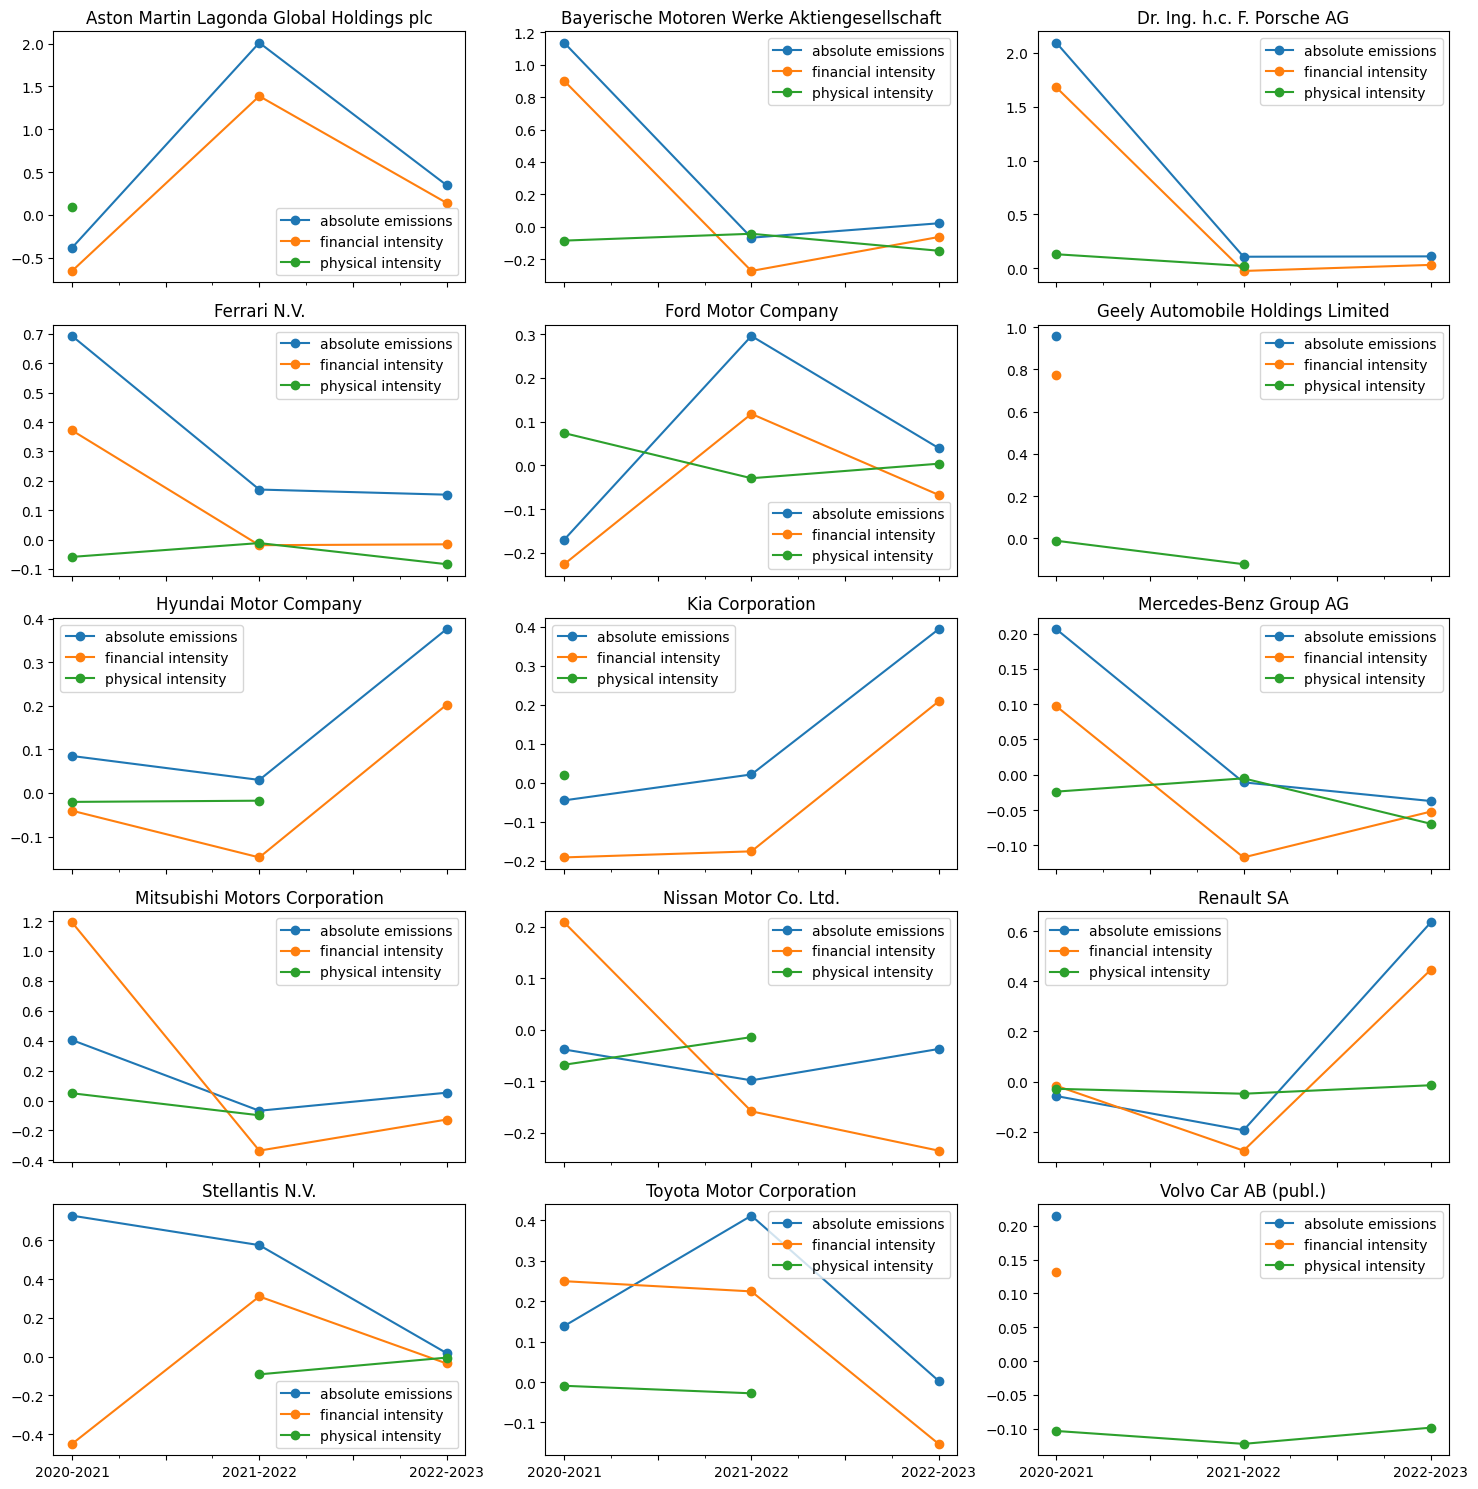

In [24]:
dict_isin_name = df[['isin', 'company' ]].drop_duplicates().set_index('isin').to_dict()['company']
dict_isin_name_auto = {k:v for k,v in dict_isin_name.items() if k in list_eq_with_int_physique}
eq = list_eq_with_int_physique[0]

fig, axes = plt.subplots(5, 3, figsize=(15, 15), sharex=True)
axes = axes.flatten()

if len(list_eq_with_int_physique) == 1:
    axes = [axes]

for ax, eq in zip(axes, list_eq_with_int_physique):
    df_selection_all_col_1.loc[
        df_selection_all_col_1['isin'] == eq, delta_years_str[1:]
    ].T.squeeze().plot(ax=ax, marker='o', label='absolute emissions')

    df_selection_all_col_3.loc[
        df_selection_all_col_3['isin'] == eq, delta_years_str[1:]
    ].T.squeeze().plot(ax=ax, marker='o', label='financial intensity')

    df_selection_all_col_5.loc[
        df_selection_all_col_5['isin'] == eq, delta_years_str[1:]
    ].T.squeeze().plot(ax=ax, marker='o', label='physical intensity')

    ax.set_title(dict_isin_name_auto[eq])
    ax.legend()

plt.tight_layout()
plt.show()

In [43]:
## Add targets

### check aston martin

In [ ]:
df_nmr_outliers_0 = pd.DataFrame(index=[selected_scope_0], columns=delta_years_str)
df_selection_outliers_0 = pd.DataFrame(False, index=[df_selection_all_col_1.set_index('isin').index], columns=delta_years_str + ['last_available_year'])
col1, col2, col3, col4 = st.columns([3, 2, 1, 3])

with col1:
    st.write("Number of equity with absolute emissions growth rate")

with col2:
    comparison_1 = st.radio(label="comparison_1", options=["superior", "inferior"], 
                            horizontal=True, key='comparison_1', label_visibility="collapsed")

with col3:
    st.write("to:")

with col4:
    threshold_1 = st.selectbox(
        label="threshold_1", options=[None, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3],
        format_func=lambda x: "Select a value" if x is None else f"{x:.1%}", 
        key='threshold_1', label_visibility="collapsed")

total_counts = df_selection_1.groupby("scope")[delta_years_str].count()
total_counts.index = ["Total"] * len(total_counts)

if threshold_1 is not None:
    if comparison_1 == 'superior':
        df_nmr_outliers_0 = (df_selection_1[delta_years_str] > threshold_1).groupby(df_selection_1["scope"]).sum()
        df_selection_outliers_0 = (df_selection_all_col_1.set_index('isin')[delta_years_str + ['last_available_year']].copy() > threshold_1) 
    elif comparison_1 == "inferior":
        df_nmr_outliers_0 = (df_selection_1[delta_years_str] <= threshold_1).groupby(df_selection_1["scope"]).sum()
        df_selection_outliers_0 = (df_selection_all_col_1.set_index('isin')[delta_years_str + ['last_available_year']].copy() <= threshold_1) 

    df_nmr_outliers_0.index = [f'nbr outliers for {selected_scope_0}']
    df_nmr_outliers_0 = pd.concat([total_counts, df_nmr_outliers_0])

In [25]:
df_hist_abs_emissions = pd.read_parquet("data/transformed_data/hist_abs_emissions.parquet")

In [26]:
df_hist_abs_emissions.query('isin=="GB00BN7CG237"').query('scope=="s3"').T

,182252
isin,GB00BN7CG237
name,Aston Martin Lagonda Global Holdings Plc
scope,s3
2019,69627.226706
2020,1551904.436901
2021,1411887.471072
2022,2883473.424715
2023,3876086.784419


In [27]:
dict_em_in_report = {"GB00BN7CG237": {'2019': 8806.94, '2020':6620.37, '2021':6446.74, '2022':11187.29, '2023':8478.32}
}

### check BMW

In [28]:
df_hist_abs_emissions.query('isin=="DE0005190003"').query('scope=="s3"').T

,129272
isin,DE0005190003
name,Bayerische Motoren Werke AG
scope,s3
2019,5277237.984748
2020,65100863.0
2021,121705367.0
2022,116586786.0
2023,133875567.0


In [29]:
dict_em_in_report = {"GB00BN7CG237": {'2019': 8806.94, '2020':6620.37, '2021':6446.74, '2022':11187.29, '2023':8478.32},
"DE0005190003": {'2019': 146225201, '2020':131255722, '2021':136757602,  '2022':129958000 ,'2023':133875567
}}

In [30]:
df_reported_em = pd.DataFrame(dict_em_in_report).T

df_reported_em_rate = df_reported_em.copy()
for y in years_str[1:]:
    y_int = int(y)
    df_reported_em_rate[f'{y_int-1}-{y_int}'] = df_reported_em_rate[y] / df_reported_em_rate[str(y_int-1)] - 1
df_reported_em_rate= df_reported_em_rate.drop(years_str, axis=1)

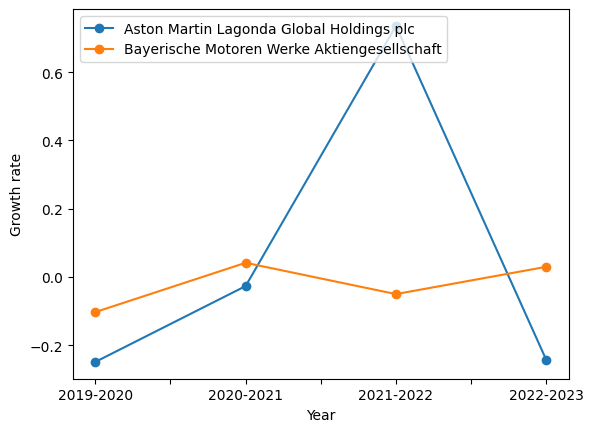

In [31]:
ax = df_reported_em_rate.T.rename(columns=dict_isin_name_auto).plot(marker='o')
ax.set_xlabel("Year")
ax.set_ylabel("Growth rate")
ax.legend( loc="upper left")

plt.show()

In [32]:
dict_isin_name_auto

{'GB00BN7CG237': 'Aston Martin Lagonda Global Holdings plc',
 'DE0005190003': 'Bayerische Motoren Werke Aktiengesellschaft',
 'DE000PAG9113': 'Dr. Ing. h.c. F. Porsche AG',
 'NL0011585146': 'Ferrari N.V.',
 'US3453708600': 'Ford Motor Company',
 'KYG3777B1032': 'Geely Automobile Holdings Limited',
 'KR7005380001': 'Hyundai Motor Company',
 'KR7000270009': 'Kia Corporation',
 'DE0007100000': 'Mercedes-Benz Group AG',
 'JP3899800001': 'Mitsubishi Motors Corporation',
 'JP3672400003': 'Nissan Motor Co. Ltd.',
 'FR0000131906': 'Renault SA',
 'NL00150001Q9': 'Stellantis N.V.',
 'JP3633400001': 'Toyota Motor Corporation',
 'SE0016844831': 'Volvo Car AB (publ.)'}

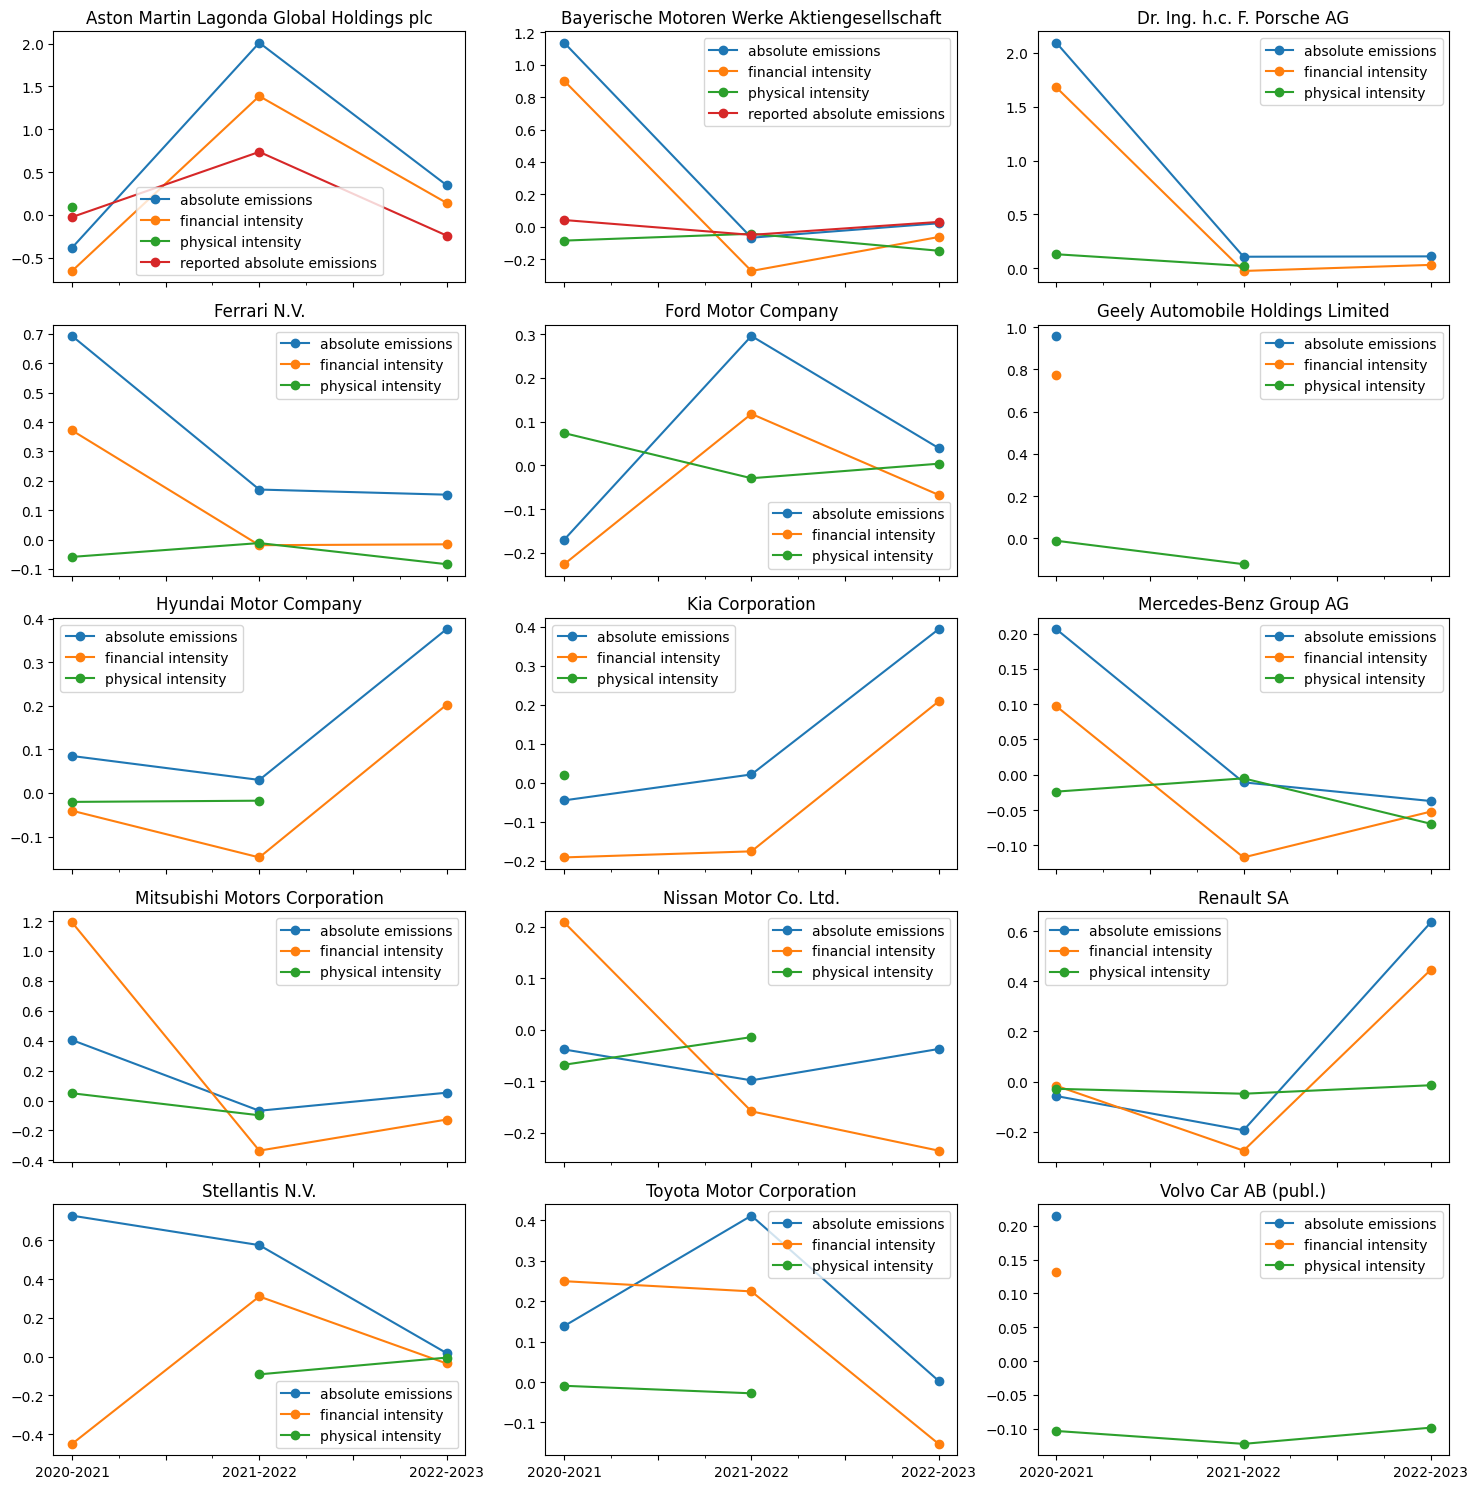

In [33]:
dict_isin_name = df[['isin', 'company' ]].drop_duplicates().set_index('isin').to_dict()['company']
dict_isin_name_auto = {k:v for k,v in dict_isin_name.items() if k in list_eq_with_int_physique}
eq = list_eq_with_int_physique[0]

fig, axes = plt.subplots(5, 3, figsize=(15, 15), sharex=True)
axes = axes.flatten()

if len(list_eq_with_int_physique) == 1:
    axes = [axes]

for ax, eq in zip(axes, list_eq_with_int_physique):
    df_selection_all_col_1.loc[
        df_selection_all_col_1['isin'] == eq, delta_years_str[1:]
    ].T.squeeze().plot(ax=ax, marker='o', label='absolute emissions')

    df_selection_all_col_3.loc[
        df_selection_all_col_3['isin'] == eq, delta_years_str[1:]
    ].T.squeeze().plot(ax=ax, marker='o', label='financial intensity')

    df_selection_all_col_5.loc[
        df_selection_all_col_5['isin'] == eq, delta_years_str[1:]
    ].T.squeeze().plot(ax=ax, marker='o', label='physical intensity')

    if eq in df_reported_em_rate.index:
        df_reported_em_rate.loc[eq, delta_years_str[1:]].T.squeeze().plot(ax=ax, marker='o', label='reported absolute emissions')

    ax.set_title(dict_isin_name_auto[eq])
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
df_reported_em_rate.T

,GB00BN7CG237,DE0005190003
2019-2020,-0.248278,-0.102373
2020-2021,-0.026227,0.041917
2021-2022,0.735341,-0.049720
2022-2023,-0.242147,0.030145


## check BMR corp sedol

In [35]:
bmr_corp = pd.read_csv("C:/Users/A_PORTEU/Downloads/HD_BMR Climate_20251105 P1.csv", sep="|")

C:\Users\A_PORTEU\AppData\Local\Temp\ipykernel_36664\2108869035.py:1: DtypeWarning: Columns (50,54,62,66,70,86,87,88,91,92,94,95,96,422,423,426,427,434,435,438,439,442,443,445,446,447,449,483,484) have mixed types. Specify dtype option on import or set low_memory=False.
  bmr_corp = pd.read_csv("C:/Users/A_PORTEU/Downloads/HD_BMR Climate_20251105 P1.csv", sep="|")


In [36]:
mapping_sedol = pd.read_csv("C:/Users/A_PORTEU/Downloads/Mapping_SEDOL_20260211.csv")
mapping_sedol['EntityId'] = mapping_sedol['EntityId'].astype("float64")

In [37]:
bmr_corp_sedol = pd.merge(bmr_corp, mapping_sedol.rename(columns={'EntityId': 'Research Entity ID', 'IdentifierTypeValue': 'SEDOL'}), on='Research Entity ID', how='left')

In [38]:
bmr_corp_sedol[['EntityName', 'SEDOL', 'Ticker']].notna().sum()

EntityName    3104602
SEDOL         3088683
Ticker        2318172
dtype: int64

# add targets

In [6]:
selected_region_0 = regions
selected_hisector_0 = list_high_impact_sector
selected_scope_0 = "s123"

In [7]:
df_selection_all_col_1 = df_eq_abs_em_rate[(df_eq_abs_em_rate['region_0'].isin(selected_region_0))&(
    df_eq_abs_em_rate['high_impact_sector'].isin(selected_hisector_0))&(
        df_eq_abs_em_rate['scope']==selected_scope_0)].copy()

df_selection_all_col_1['last_available_year'] = df_selection_all_col_1[delta_years_str[::-1]].bfill(axis=1).iloc[:, 0]

df_selection_1 = df_selection_all_col_1[['scope'] + delta_years_str + ['last_available_year']].copy()

In [8]:
df_nmr_outliers_0 = pd.DataFrame(index=[selected_scope_0], columns=delta_years_str)
df_selection_outliers_0 = pd.DataFrame(False, index=[df_selection_all_col_1.set_index('isin').index], columns=delta_years_str + ['last_available_year'])

comparison_1 ="superior"
threshold_1 = 0.1

total_counts = df_selection_1.groupby("scope")[delta_years_str].count()
total_counts.index = ["Total"] * len(total_counts)

if threshold_1 is not None:
    if comparison_1 == 'superior':
        df_nmr_outliers_0 = (df_selection_1[delta_years_str] > threshold_1).groupby(df_selection_1["scope"]).sum()
        df_selection_outliers_0 = (df_selection_all_col_1.set_index('isin')[delta_years_str + ['last_available_year']].copy() > threshold_1) 
    elif comparison_1 == "inferior":
        df_nmr_outliers_0 = (df_selection_1[delta_years_str] <= threshold_1).groupby(df_selection_1["scope"]).sum()
        df_selection_outliers_0 = (df_selection_all_col_1.set_index('isin')[delta_years_str + ['last_available_year']].copy() <= threshold_1) 

    df_nmr_outliers_0.index = [f'nbr outliers for {selected_scope_0}']
    df_nmr_outliers_0 = pd.concat([total_counts, df_nmr_outliers_0])

In [20]:
df_selection_outliers_0

,2019-2020,2020-2021,2021-2022,2022-2023,last_available_year
isin,,,,,
US88025U1097,True,True,True,False,False
US3369011032,True,False,True,True,True
INE466L01038,False,False,False,True,True
US74734M1099,False,False,False,False,False
CNE100002RZ2,True,True,False,False,False
...,...,...,...,...,...
DE0007500001,True,True,False,False,False
CH0033361673,False,True,True,False,False
US90354D1046,False,False,False,False,False


In [13]:
dict_mapping_targets_ctgry = {
    'Ambitious Target': 'is_ambitious_target',
    'Approved SBT': 'is_approved_sbt_target',
    "Committed SBT": 'is_committed_sbt_target',
    'Non-Ambitious Target': 'is_target_non_ambitious',
    'No Target': 'is_no_target'}

In [14]:
selected_label = ['Ambitious Target', 'Approved SBT', "Committed SBT"]
selected_targets = [dict_mapping_targets_ctgry[lbl] for lbl in selected_label]
selected_targets

['is_ambitious_target', 'is_approved_sbt_target', 'is_committed_sbt_target']

In [31]:
df_targets = df.query('scope=="s1"')[['isin'] + list(dict_mapping_targets_ctgry.values())].set_index('isin')

In [34]:
df_selection_outliers_1_targets = pd.concat([df_selection_outliers_0, df_targets.loc[df_selection_outliers_0.index]], axis=1)
df_selection_outliers_1_targets['has_selected_target'] = df_selection_outliers_1_targets[selected_targets].any(axis=1)
df_selection_outliers_1_targets = df_selection_outliers_1_targets.drop(list(dict_mapping_targets_ctgry.values()), axis=1)

In [41]:
pd.concat([df_selection_outliers_1_targets[df_selection_outliers_1_targets['has_selected_target']][delta_years_str].sum(),
           df_selection_outliers_1_targets[delta_years_str].sum()], axis=1, keys=['with targets', 'total']).T

,2019-2020,2020-2021,2021-2022,2022-2023
with targets,1629,1215,951,596
total,4343,3660,3242,2028


In [38]:
df_selection_outliers_1_targets[delta_years_str].sum()

2019-2020    4343
2020-2021    3660
2021-2022    3242
2022-2023    2028
dtype: int64

In [42]:
df

,isin,scope,average_expected_rate,nbr_expected_rate_available,is_ambitious_target,is_approved_sbt_target,is_committed_sbt_target,is_target_sbt_or_ambitious,is_target_sbt_or_ambitious_or_commited,is_target_non_ambitious,...,company,nace,company_free_float_market_cap,region_0,high_impact_sector,region,r_s_mc_weight,r_mc_weight,s_mc_weight,is_relevant_scopes
0,US88025U1097,s1,0.0,4.0,False,False,False,False,False,False,...,10x Genomics Inc.,"""32.5""",1344.736127,Dev America US,Industrials,North America,0.000076,0.000020,0.000052,False
1,US88025U1097,s2,0.0,4.0,False,False,False,False,False,False,...,10x Genomics Inc.,"""32.5""",1344.736127,Dev America US,Industrials,North America,0.000076,0.000020,0.000052,False
2,US88025U1097,s3,0.0,4.0,False,False,False,False,False,False,...,10x Genomics Inc.,"""32.5""",1344.736127,Dev America US,Industrials,North America,0.000076,0.000020,0.000052,False
3,US88025U1097,s3_u,NaN,NaN,None,None,None,None,None,None,...,10x Genomics Inc.,"""32.5""",1344.736127,Dev America US,Industrials,North America,0.000076,0.000020,0.000052,False
4,US88025U1097,s3_d,NaN,NaN,None,None,None,None,None,None,...,10x Genomics Inc.,"""32.5""",1344.736127,Dev America US,Industrials,North America,0.000076,0.000020,0.000052,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117100,DK0060094928,s23,NaN,NaN,None,None,None,None,None,None,...,Ørsted A/S,"""35.12""",18239.085704,Dev Europe Other,Electric utilities,Developed Europe,0.549977,0.004715,0.007662,False
117101,DK0060094928,s13_u,NaN,NaN,None,None,None,None,None,None,...,Ørsted A/S,"""35.12""",18239.085704,Dev Europe Other,Electric utilities,Developed Europe,0.549977,0.004715,0.007662,False
117102,DK0060094928,s13_d,NaN,NaN,None,None,None,None,None,None,...,Ørsted A/S,"""35.12""",18239.085704,Dev Europe Other,Electric utilities,Developed Europe,0.549977,0.004715,0.007662,False
117103,DK0060094928,s23_u,NaN,NaN,None,None,None,None,None,None,...,Ørsted A/S,"""35.12""",18239.085704,Dev Europe Other,Electric utilities,Developed Europe,0.549977,0.004715,0.007662,False


In [54]:
df_selection_1_targets = pd.merge(df_selection_all_col_1, df_targets.reset_index(), on='isin')
df_selection_1_targets['has_selected_target'] = df_selection_1_targets[selected_targets].fillna(False).any(axis=1)
pd.DataFrame([{'with targets': df_selection_1_targets['has_selected_target'].sum(), 'total': df_selection_1_targets['isin'].count()}]).T


C:\Users\A_PORTEU\AppData\Local\Temp\ipykernel_34780\3773912809.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_selection_1_targets['has_selected_target'] = df_selection_1_targets[selected_targets].fillna(False).any(axis=1)


,0
with targets,2341
total,7560


In [46]:
df_targets

,is_ambitious_target,is_approved_sbt_target,is_committed_sbt_target,is_target_non_ambitious,is_no_target
isin,,,,,
US88025U1097,False,False,False,False,True
US3369011032,False,False,False,False,True
INE466L01038,False,False,False,False,True
US74734M1099,False,False,False,False,True
CNE100002RZ2,False,False,False,False,True
...,...,...,...,...,...
DE0007500001,False,True,False,False,False
CH0033361673,True,False,False,False,False
US90354D1046,None,None,None,None,True


In [ ]:
    df_selection_outliers_1_targets = pd.concat([df_selection_all_col_1.set_in, df_targets.loc[df_selection_outliers_1.index]], axis=1)
    df_selection_outliers_1_targets['has_selected_target'] = df_selection_outliers_1_targets[selected_targets].fillna(False).any(axis=1)
    df_selection_outliers_1_targets = df_selection_outliers_1_targets.drop(list(dict_mapping_targets_ctgry.values()), axis=1)